## Nichtlineare Ausgleichsrechnung, Gauss-Newton und Levenberg-Marquardt
Ein nichtlineares Ausgleichsproblem ist ein Minimierungsproblem

$$
    |\vec{f}(\vec{p})|^2 \stackrel!= \textrm{min}
$$

für eine Funktion $\vec{f}:\mathbb{R}^n \to \mathbb{R}^{N}$. 

### Gauss-Newton Verfahren
Das **Gauss-Newton**-Verfahren ist sehr ähnlich, wie das Newtonverfahren für Gleichungssysteme:
  
* Wähle Startwerte $\vec{p}$
* Für $k = 1, 2, \ldots$
    * Löse das lineare Ausgleichsproblem $|\vec{f}(\vec{p}) + J \, \vec{\delta}|^2 \to \textrm{min}$
    * Setze $\vec{p} := \vec{p} + \vec{\delta}$

$J$ bezeichnet die Jacobimatrix von $\vec{f}$ an der Stelle $\vec{p}$.

Genau wie das Gaussverfahren, kann Gauss-Newton konvergieren oder auch nicht, ahängig von der konkreten Aufgabe und dem Startwert $\vec{p}$. Die Idee dahinter ist, dass

$$
    \vec{f}(\vec{p} + \vec{\delta}) \approx \vec{f}(\vec{p}) + J \vec{\delta}
$$

### Levenberg-Marquardt Verfahren
Das **Levenberg-Marquardt** Verfahren ist eine Erweiterung von Gauss-Newton mit dem Ziel, robustere Konvergenz zu erreichen.

* Wähle $0 < \beta_0 < \beta_1$. Diese Parameter bleiben während der Iteration konstant.
* Wähle Startwert $\vec{p}$ und $\mu > 0$
* Für $k = 1, 2, \ldots$
    * Löse das lineare Ausgleichsproblem $|\vec{f}(\vec{p}) + J \, \vec{\delta}|^2 + \mu^2 |\vec{\delta}|^2 \to \textrm{min}$
    * Berechne $\rho$ (s. unten)
    * Falls $\rho < \beta_0$: setze $\mu := 2 \mu$ (und behalte $\vec{p}$, d.h. das berechnete $\delta$ wird verworfen)
    * Falls $\beta_0 \leq \rho < \beta_1$: setze $\vec{p} := \vec{p} + \vec{\delta}$ (und behalte $\mu$)
    * Falls $\beta_1 < \rho$: setze $\mu := \mu/2$ und $\vec{p} := \vec{p} + \vec{\delta}$   

Die Idee der Minimierung ist, die "Schrittweite" $|\delta|$ zu beschränken, indem der Zusatzterm $\mu^2 |\vec{\delta}|^2$ in die Minimierung einfliesst. Die Minimierung von 
$$
    |\vec{f}(\vec{p}) + J \, \vec{\delta}|^2 + \mu^2 |\vec{\delta}|^2
$$
ist jeweils ein *lineares* Ausgleichsproblem und kann erzielt werden, indem an die Jacobimatrix $J$ eine skalierte Einheitsmatrix $\mu \cdot E$ und an $\vec{f}(\vec{p})$ ein Nullvektor passender Länge angehängt wird.
 
Die Berechnung von $\rho$ ist

$$
    \rho = \frac{|\vec{f}(\vec{p})|^2 - |\vec{f}(\vec{p} + \vec{\delta})|^2}{|\vec{f}(\vec{p})|^2 - |\vec{f}(\vec{p}) + J\, \vec{\delta}|^2}
$$

Hier ist die Idee, die echte Verbesserung (Zähler) mit der effektiv erreichten Verbesserung (Nenner) zu vergleichen 

# Aufgabe 1: Gauss-Newton
Implementieren Sie das **Gauss-Newton Verfahren** und testen Sie es an dem Modell
$$
    y_i = u_0 \cdot e^{- a t} \cdot \sin (\omega t + \varphi)
$$

mit den Parametern $(u_0, a, \omega, \varphi)$ mit den Daten, die von dem folgenden Abschnitt erzeugt werden. Wälen Sie Startwerte, die nicht zu weit von den echten Werten (s. Code) abweichen. Experimentieren Sie ein wenig mit den Konvergenzeigenschaften von Gauss-Newton.

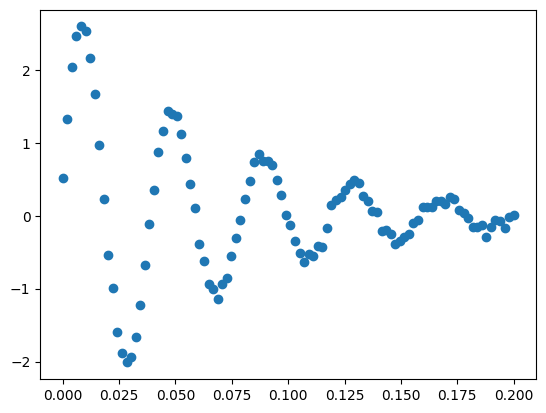

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Daten erzeugen mit den Parametern:
u0 = 3
a = 15
w = 25 * 2 * np.pi
phi = 10 * np.pi / 180

noiseAmp = 0.05 # Amplitude der Messfehler (kein Parameter des Modells)

N = 100
t = np.linspace(0, 5 * 2 * np.pi / w, 100)
y = u0 * np.exp(-a * t) * np.sin(w*t + phi) + noiseAmp * np.random.randn(N)

plt.scatter(t, y)

In [ ]:
# Startwerte 
u0 = <<snipp>>

p0 = np.array([u0, a, w, phi])

<<snipp>>    

plt.scatter(t, y, color = [.6,.6,.6])
plt.plot(t, f(*p0), color = "orange", label = "start") # Startwerte
plt.plot(t, f(*p), color = "green", label = "end")     # Nach Iteration

plt.legend()



# Aufgabe 2: Levenberg-Marquardt 
Implementieren Sie das **Levenberg-Marquardt Verfahren** und verwenden Sie dieses zur Bestimmung der Parameter

$$
    \vec{p} = (p_0, \ldots, p_6)
$$

des Modells

$$
    y = p_0 + p_1 \cdot \omega + p_2 \cdot \omega^2 + p_3 \cdot \omega^3 + p_4 \cdot \ell(p_5, p_6, {\color{gray} \omega})
$$

mit 

$$
    \ell(p_5, p_6, {\color{gray} \omega}) = \frac{1}{1 + 4 \cdot \left( \frac{\omega - p_5}{p_6} \right)^2}
$$

und testen Sie dieses an den Daten im file dataP7.txt.  

Das Modell ist dasselbe, wie in Praktikum 5 (lineare Ausgleichsrechnung), aber es sind zwei zusätzliche Parameter hinzugekommen, die in P5 als bekannt vorausgesetzt wurden. Das Modell ist immer noch linear in den Parametern $p_0, \ldots, p_4$. Sie werden feststellen, dass diese in der Jacobimatrix gar nicht vorkommen. Ein Teil der Jacobimatrix entspricht der Matrix des linearen Ausgleichsproblem aus P5.

* Verwenden Sie die QR-Zerlegung aus P5 zur Lösung der linearen Ausgleichsprobleme
* Skalieren Sie die $\omega$-Achse!
* Tipp zur besseren Lesbarkeit: erstellen sie Hilfsfunktionen für die Funktion $\ell$ die den Peak darstellt sowie für die benötigten partiellen Ableitungen davon.
* Bestimmen Sie Startwerte, indem Sie die Modellfunktion plotten und mit den Daten vergleichen. Versuchen Sie nicht, die Startwerte allzu genau zu machen - schliesslich wollen Sie sehen, wie gut Levenberg-Marquardt mit mittelmässigen Startwerten zurecht kommt!

**Bemerkung**: Die Daten sind nicht exakt identisch mit den Daten aus P5

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

data = np.genfromtxt("dataP7.txt")
w, y = data.T

w  = <<snipp>> # skalieren

plt.plot(w, y, '.', color = [.7,.7,.7]);

In [ ]:
p0 = <<snipp>>

<<snipp>> 

plt.scatter(w, y, color = [.6,.6,.6])
plt.plot(w, m(*p0), color = "orange", label = "start") # mit Startwerten
plt.plot(w, m(*p), color = "green", label = "end")     # nach levenberg-Marquardt

plt.legend()

print("gefundene Parameter: ", p)